In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:

import torch
import torch.nn.functional as F
import os
from monai.networks.nets.autoencoderkl import AutoencoderKL
# from generative.networks.nets import AutoencoderKL
from monai.utils import set_determinism
from preprocessing.load_dataset import list_files_with_extension
import numpy as np
import os
from tqdm import tqdm

def uncrop_mri(cropped_data, original_shape=(256, 256, 256), target_shape=(160, 176, 208)):
    """
    Paste the cropped MRI back into its original position within the full image shape.
    
    Parameters:
        cropped_data (ndarray): The cropped 3D MRI array.
        original_shape (tuple): The shape of the full original volume.
        target_shape (tuple): The shape used during cropping.
    
    Returns:
        ndarray: The uncropped MRI with the cropped region placed at the original location.
    """
    full_data = np.zeros(original_shape, dtype=cropped_data.dtype)

    start = [48, 38, 10]
    end = [start[i] + cropped_data.shape[i] for i in range(3)]

    full_data[start[0]:end[0], start[1]:end[1], start[2]:end[2]] = cropped_data

    return full_data

### Input data
# Path to dataset
load_ds_path = "/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/"
# Path to save embeddings
save_ds_path = "/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni__emb/"
os.makedirs(save_ds_path, exist_ok=True) # create if not exist
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_path = "./data/pretrained_models/autoencoder_puglisi.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]


### Loading VAE
set_determinism(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load trained networks
autoencoder = AutoencoderKL(spatial_dims=3, 
                            in_channels=1, 
                            out_channels=1, 
                            latent_channels=3,
                            channels=(64, 128, 128, 128),
                            num_res_blocks=2, 
                            norm_num_groups=32,
                            norm_eps=1e-06,
                            attention_levels=(False, False, False, False), 
                            with_decoder_nonlocal_attn=False, 
                            with_encoder_nonlocal_attn=False)
autoencoder.to(device)

# Load pretrained model VAE
state_dict = torch.load(ckpt_path)
autoencoder.load_old_state_dict(state_dict)
print("VAE weights successfully loaded!")

### Loading the dataset
# Parched dataset file paths
file_paths, file_names = list_files_with_extension(load_ds_path, extension=extension)
file_names.sort()

print("Files to be processed: ")
[print(os.path.join(load_ds_path, file_path, file_name)) for file_path, file_name in zip(file_paths, file_names)]

# Initialization of lists
list_z_mu = []
list_sample_id = []

# Loop: Load the batched dataset
for file_path, file_name in zip(file_paths, file_names):
    file_to_load = os.path.join(load_ds_path, file_path, file_name)
    data = np.load(file_to_load)
    images = data['images']
    # segmentations = data['segmentations'] # unused
    sample_ids = data['ids']
    # Optionally: close file if it's a lazy loader (not strictly needed if you load all arrays)
    data.close()

    # Loop over batch
    for img, sample_id in tqdm(zip(images, sample_ids), desc=f"Processing {file_to_load}", total=len(images), ncols=180):
    
        # Preparing image for using as input of the VAE
        img = np.expand_dims(img, axis=0).astype(np.float32) / 255.0
        # img = np.flip(np.transpose(img, (0, 2, 3, 1)), axis=2).copy()
        img = uncrop_mri(img, original_shape=(256, 256, 256), target_shape=(160, 176, 208))
        current_shape = list(img.shape)
        img = torch.tensor(img)

        # Calculate padding: (left, right, top, bottom, front, back)
        pad_d = (0, target_shape[3] - current_shape[3])  # depth (no change)
        pad_h = (0, target_shape[2] - current_shape[2])  # height
        pad_w = (0, target_shape[1] - current_shape[1])  # width

        # Flatten padding list: reverse order for F.pad â†’ (D, H, W)
        padding = pad_d + pad_h + pad_w  # [depth, height, width]

        # Pad image
        padded_img = F.pad(img, padding).unsqueeze(0).to(device)

        # Inference through autoencoder
        autoencoder.eval()
        with torch.no_grad():
            reconstruction, z_mu, z_sigma = autoencoder(padded_img)  # add batch dim
            reconstruction = reconstruction.squeeze(0)  # remove batch dim

        break
    break

# Visualize middle slice of the original and reconstructed images
def show_slices(tensor1, tensor2, axis=0):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    idx = tensor1.shape[axis] // 2
    slice1 = tensor1[0].select(dim=axis, index=idx).cpu()
    slice2 = tensor2[0].select(dim=axis, index=idx).cpu()

    axs[0].imshow(slice1, cmap="gray")
    axs[0].set_title("Original (padded)")

    axs[1].imshow(slice2, cmap="gray")
    axs[1].set_title("Reconstruction")

    plt.tight_layout()
    plt.show()

# Show middle slice along depth axis (0)
original_img = padded_img.squeeze(0)
show_slices(original_img, reconstruction, axis=1)

VAE weights successfully loaded!
Files to be processed: 
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0001.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0002.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0003.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0004.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0005.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0006.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0007.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0008.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0009.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0010.npz
/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0011.npz
/mimer/NOBACKUP/groups/biomedicalimaging-

Processing /mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/batched_adni/batch_0001.npz:   0%|                                                        | 0/1000 [00:09<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.00 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.31 GiB is free. Including non-PyTorch memory, this process has 12.25 GiB memory in use. Of the allocated memory 9.12 GiB is allocated by PyTorch, and 3.01 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [3]:
padded_img.shape

torch.Size([1, 1, 256, 256, 256])

In [15]:
current_shape

[1, 160, 176, 208]

In [4]:
img.max()

tensor(1.)

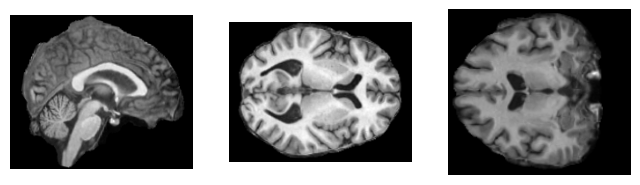

In [10]:
mri_image = images[0]
# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [11]:
mri_image.shape

(160, 176, 208)

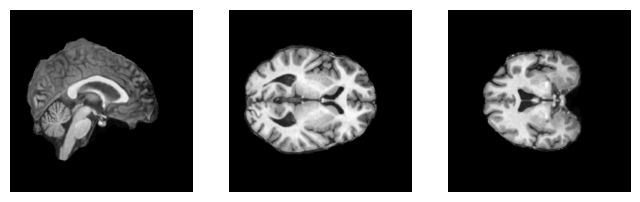

(224, 160, 160)

In [12]:
mri_image = images[0]

def uncrop_mri(cropped_data, original_shape=(256, 256, 256), target_shape=(160, 176, 208)):
    """
    Paste the cropped MRI back into its original position within the full image shape.
    
    Parameters:
        cropped_data (ndarray): The cropped 3D MRI array.
        original_shape (tuple): The shape of the full original volume.
        target_shape (tuple): The shape used during cropping.
    
    Returns:
        ndarray: The uncropped MRI with the cropped region placed at the original location.
    """
    full_data = np.zeros(original_shape, dtype=cropped_data.dtype)

    start = [48, 38, 10]
    end = [start[i] + cropped_data.shape[i] for i in range(3)]

    full_data[start[0]:end[0], start[1]:end[1], start[2]:end[2]] = cropped_data

    return full_data


mri_image = uncrop_mri(mri_image, original_shape=(256, 256, 256), target_shape=(160, 176, 208))

# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()
mri_image_2.shape

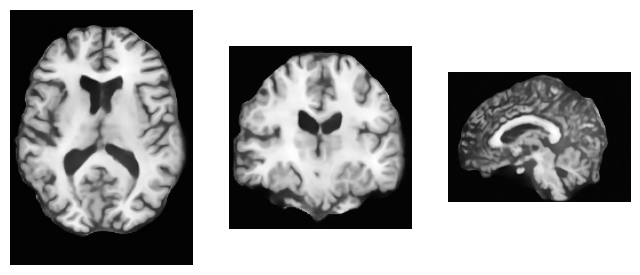

In [7]:
mri_image = reconstruction.cpu().numpy()[0]
# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [6]:
reconstruction.cpu().numpy().shape

(1, 160, 224, 160)